## Customer Segmentation (Income vs Spending)

K-Means clustering was used to segment customers based on Annual Income and Spending Score. The model identified 4 distinct customer groups:

* Cluster 0: Budget customers with medium income and low spending.
* Cluster 1: High-spending customers with medium income.
* Cluster 2: Premium customers with high income and high spending.
* Cluster 3: Potential customers with high income but low spending.

### Insight

Customers with similar income levels can have very different spending behaviors, making segmentation important for targeted marketing.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("Shopping Mall Customer Segmentation Data .csv")
df.head()

,Customer ID,Age,Gender,Annual Income,Spending Score
0,d410ea53-6661-42a9-ad3a-f554b05fd2a7,30,Male,151479,89
1,1770b26f-493f-46b6-837f-4237fb5a314e,58,Female,185088,95
2,e81aa8eb-1767-4b77-87ce-1620dc732c5e,62,Female,70912,76
3,9795712a-ad19-47bf-8886-4f997d6046e3,23,Male,55460,57
4,64139426-2226-4cd6-bf09-91bce4b4db5e,24,Male,153752,76


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15079 entries, 0 to 15078
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Customer ID     15079 non-null  object
 1   Age             15079 non-null  int64 
 2   Gender          15079 non-null  object
 3   Annual Income   15079 non-null  int64 
 4   Spending Score  15079 non-null  int64 
dtypes: int64(3), object(2)
memory usage: 589.1+ KB


In [4]:
df = df.drop("Customer ID",axis=1)
order = {
    "Male":0,
    "Female":1
}
df["Gender"] = df["Gender"].map(order)

In [5]:
df.head()

,Age,Gender,Annual Income,Spending Score
0,30,0,151479,89
1,58,1,185088,95
2,62,1,70912,76
3,23,0,55460,57
4,24,0,153752,76


In [6]:
df.describe()

,Age,Gender,Annual Income,Spending Score
count,15079.000000,15079.000000,15079.000000,15079.000000
mean,54.191591,0.496319,109742.880562,50.591617
std,21.119207,0.500003,52249.425866,28.726977
min,18.000000,0.000000,20022.000000,1.000000
25%,36.000000,0.000000,64141.000000,26.000000
50%,54.000000,0.000000,109190.000000,51.000000
75%,72.000000,1.000000,155008.000000,75.000000
max,90.000000,1.000000,199974.000000,100.000000


In [7]:
X = df[["Annual Income", "Spending Score"]]

In [8]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

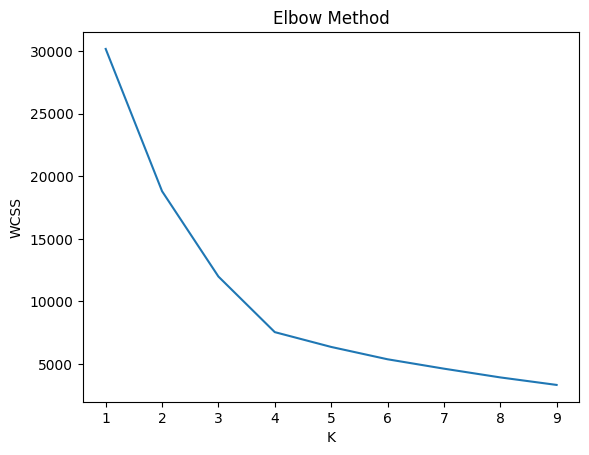

In [9]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

for k in range(1, 10):
    model = KMeans(n_clusters=k, random_state=42)
    model.fit(X_scaled)
    wcss.append(model.inertia_)

plt.plot(range(1, 10), wcss)
plt.xlabel("K")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

In [10]:
kmeans = KMeans(n_clusters=4, random_state=42)
y = kmeans.fit_predict(X_scaled)

df["cluster"] = y

In [11]:
df.groupby("cluster").mean(numeric_only=True)

,Age,Gender,Annual Income,Spending Score
cluster,,,,
0,54.250906,0.490419,65147.551787,25.788193
1,53.962777,0.495248,64963.854541,75.503696
2,54.368254,0.494180,155276.082275,75.115873
3,54.183338,0.505892,156258.256783,25.577144


In [12]:
from sklearn.metrics import silhouette_score

for k in range(2, 8):
    kmeans = KMeans(n_clusters=k, random_state=42)
    y = kmeans.fit_predict(X_scaled)
    
    score = silhouette_score(X_scaled, y)
    print(f"K={k}, Score={score}")

K=2, Score=0.3553667213350779
K=3, Score=0.375019535022639
K=4, Score=0.40620450351341364
K=5, Score=0.39061699548257833
K=6, Score=0.37765427497159954
K=7, Score=0.3657072088112056


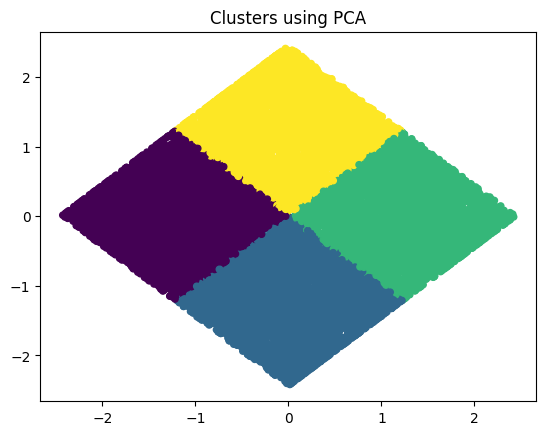

In [13]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df["cluster"], s=20)
plt.title("Clusters using PCA")
plt.show()